# De Neuronas Biológicas a Neuronas Artificiales



Sorprendentemente, las RNA (redes neuronales artificiales) llevan bastante tiempo entre nosotros: fueron presentadas por primera vez en 1943 por el neurofisiólogo Warren McCulloch y el matemático Walter Pitts. 

En su artículo histórico, "A Logical Calculus of Ideas Immanent in Nervous Activity" ("Un cálculo lógico de las ideas inmanentes en la actividad nerviosa"), McCulloch y Pitts presentaron un modelo computacional simplificado de cómo las neuronas biológicas podrían trabajar juntas en los cerebros animales para realizar cálculos complejos mediante lógica proposicional. 

Esta fue la primera arquitectura de red neuronal artificial. 

Desde entonces se han inventado muchas otras arquitecturas, como verás más adelante.



Los primeros éxitos de las RNA llevaron a la creencia generalizada de que pronto estaríamos conversando con máquinas verdaderamente inteligentes. 

Cuando quedó claro en la década de 1960 que esta promesa no se cumpliría (al menos durante bastante tiempo), la financiación se desvió hacia otros campos, y las RNA entraron en un largo invierno. 

A principios de la década de 1980 se inventaron nuevas arquitecturas y se desarrollaron mejores técnicas de entrenamiento, lo que despertó un renovado interés por el conexionismo, es decir, el estudio de las redes neuronales. 

Pero el progreso fue lento, y hacia la década de 1990 se habían inventado otras técnicas de aprendizaje automático muy potentes, como las máquinas de vectores de soporte. 

Estas técnicas parecían ofrecer mejores resultados y bases teóricas más sólidas que las RNA, así que una vez más el estudio de las redes neuronales quedó en pausa.



Actualmente estamos siendo testigos de una nueva ola de interés en las RNA. 

¿Se extinguirá esta ola como las anteriores? 

Bueno, aquí van algunas buenas razones para creer que esta vez es diferente y que el renovado interés en las RNA tendrá un impacto mucho más profundo en nuestras vidas:



• Ahora existe una enorme cantidad de datos disponibles para entrenar redes neuronales, y las RNA frecuentemente superan a otras técnicas de aprendizaje automático en problemas muy grandes y complejos.



• El tremendo aumento en la potencia de cómputo desde la década de 1990 hace posible ahora entrenar grandes redes neuronales en un tiempo razonable. 

Esto se debe en parte a la ley de Moore (el número de componentes en los circuitos integrados se ha duplicado aproximadamente cada 2 años durante los últimos 50 años), pero también gracias a la industria de los videojuegos, que ha estimulado la producción masiva de potentes unidades de procesamiento gráfico (GPU): las tarjetas GPU se diseñaron inicialmente para acelerar gráficos, pero resulta que las redes neuronales realizan cálculos similares (como multiplicaciones de matrices grandes), por lo que también pueden acelerarse mediante GPU. 

Además, las plataformas en la nube han puesto este poder al alcance de todos.



• Los algoritmos de entrenamiento han mejorado. Para ser honestos, son solo ligeramente diferentes de los utilizados en la década de 1990, pero estos ajustes relativamente pequeños han tenido un enorme impacto positivo.



• Algunas limitaciones teóricas de las RNA han resultado ser inofensivas en la práctica. 

Por ejemplo, mucha gente pensaba que los algoritmos de entrenamiento de las RNA estaban condenados porque era probable que se quedaran atascados en óptimos locales, pero resulta que esto no es un gran problema en la práctica, especialmente en redes neuronales más grandes: los óptimos locales a menudo funcionan casi tan bien como el óptimo global.



• La invención de la arquitectura Transformer en 2017 (ver Capítulo 15) ha cambiado las reglas del juego: puede procesar y generar todo tipo de datos (por ejemplo, texto, imágenes, audio), a diferencia de las arquitecturas anteriores más especializadas, y funciona muy bien en una amplia variedad de tareas, desde la robótica hasta el plegamiento de proteínas. 

Además, escala bastante bien, lo que ha hecho posible entrenar modelos base muy grandes que pueden reutilizarse en muchas tareas diferentes, posiblemente con un poco de ajuste fino (esto es transfer learning o aprendizaje por transferencia), o simplemente indicándole al modelo de la manera correcta (esto es in-context learning o aprendizaje en contexto, ICL). 

Por ejemplo, puedes darle unos pocos ejemplos de la tarea en cuestión (esto es few-shot learning o aprendizaje con pocos ejemplos, FSL), o pedirle que razone paso a paso (esto es chain-of-thought prompting o instrucciones de cadena de pensamiento, CoT). ¡Es un mundo nuevo!



• Las RNA parecen haber entrado en un círculo virtuoso de financiación y progreso. 

Productos asombrosos basados en RNA aparecen regularmente en los titulares de noticias, lo que atrae cada vez más atención y financiación hacia ellas, lo que resulta en más progreso y productos aún más asombrosos. 

La IA ya no solo impulsa productos en las sombras: desde que se lanzaron chatbots como ChatGPT, el público en general ahora interactúa directamente a diario con asistentes de IA, y las grandes empresas tecnológicas compiten ferozmente por conquistar este mercado gigantesco: el ritmo de innovación es vertiginoso.

# Práctica de Python para implementar el modelo de McCulloch-Pitts

Aquí tienes una práctica en Python que te permite implementar el modelo original de McCulloch-Pitts (mencionado en el texto) y luego explorar algunos de los conceptos clave: compuertas lógicas con neuronas artificiales, el problema de los óptimos locales, y una demostración conceptual de few-shot / in-context learning.

La práctica tiene tres partes conectadas directamente con el texto:



1. **Neurona de McCulloch-Pitts**: implementas la neurona original de 1943 y construyes compuertas AND/OR/NOT con ella. Hay un TODO para XOR, que justamente ilustra por qué las RNA de una sola capa se estancaron en los años 60.
2. **Óptimos locales vs. globales**: una simulación con descenso por gradiente desde múltiples puntos de partida, para comprobar de forma práctica la afirmación del texto de que los óptimos locales "suelen funcionar casi tan bien como el global".
3. **Few-shot / in-context learning**: una analogía simplificada (sin RNA real) para entender la diferencia entre aprender de ejemplos en el prompt vs. reentrenar el modelo.



Al final hay preguntas de reflexión para conectar el código con los conceptos del texto.

# PRÁCTICA: De Neuronas Biológicas a Neuronas Artificiales



Esta práctica profundiza en el texto sobre la historia de las RNA implementando el modelo original de McCulloch-Pitts (1943) y explorando algunos de los conceptos mencionados: lógica proposicional, óptimos
locales vs. globales, y few-shot/in-context learning.



Cada ejercicio incluye una breve explicación y código para completar (marcado con TODO) o ya resuelto para que lo ejecutes y experimentes. 


In [1]:

import random
import math


In [3]:

# ============================================================
# EJERCICIO 1: La neurona de McCulloch-Pitts (1943)
# ============================================================
# El texto dice que McCulloch y Pitts modelaron cómo las neuronas biológicas podrían combinarse para realizar 
# cálculos usando "lógica proposicional". Su neurona es muy simple:
#
#   - Recibe una o más entradas binarias (0 o 1)
#   - Suma las entradas (con posibles pesos +1 o -1, o inhibitorias)
#   - Se activa (salida = 1) si la suma alcanza un umbral; si no, salida = 0
#
# Implementemos una neurona genérica de McCulloch-Pitts:

def neurona_mcculloch_pitts(entradas, pesos, umbral):
    """
    entradas: lista de 0s y 1s
    pesos: lista de pesos (mismo tamaño que entradas)
    umbral: valor que debe alcanzar o superar la suma ponderada
    """
    suma = sum(e * p for e, p in zip(entradas, pesos))
    return 1 if suma >= umbral else 0


In [4]:


# Con esta única neurona podemos construir compuertas lógicas,
# tal como proponían McCulloch y Pitts:

def AND(a, b):
    # Ambas entradas deben ser 1 para activarse -> umbral = 2, pesos = 1,1
    return neurona_mcculloch_pitts([a, b], [1, 1], umbral=2)

def OR(a, b):
    # Basta con que una entrada sea 1 -> umbral = 1, pesos = 1,1
    return neurona_mcculloch_pitts([a, b], [1, 1], umbral=1)

def NOT(a):
    # Peso negativo (inhibitorio): si a=1, la suma baja del umbral
    return neurona_mcculloch_pitts([a], [-1], umbral=0)



In [5]:

print("=== Ejercicio 1: Compuertas lógicas con neuronas de McCulloch-Pitts ===")
for x in [0, 1]:
    for y in [0, 1]:
        print(f"AND({x},{y}) = {AND(x, y)}   OR({x},{y}) = {OR(x, y)}")
print(f"NOT(0) = {NOT(0)}   NOT(1) = {NOT(1)}")
print()


=== Ejercicio 1: Compuertas lógicas con neuronas de McCulloch-Pitts ===
AND(0,0) = 0   OR(0,0) = 0
AND(0,1) = 0   OR(0,1) = 1
AND(1,0) = 0   OR(1,0) = 1
AND(1,1) = 1   OR(1,1) = 1
NOT(0) = 1   NOT(1) = 0



In [ ]:

# TODO 1: Implementa la compuerta XOR usando varias neuronas de
# McCulloch-Pitts combinadas (una sola neurona NO puede resolver XOR,
# ¡es justo el problema que llevó al primer "invierno" de las RNA!).
# Pista: XOR(a,b) = AND(OR(a,b), NOT(AND(a,b)))


In [6]:

def XOR(a, b):
    # TODO: complétalo usando las funciones AND, OR, NOT ya definidas
    return AND(OR(a,b), NOT(AND(a,b))) 


In [7]:

for x in [0,1]:
    for y in [0,1]:
        print(f'XOR({x}, {y}) = {XOR(x,y)}')

XOR(0, 0) = 0
XOR(0, 1) = 1
XOR(1, 0) = 1
XOR(1, 1) = 0


[Video de apoyo al inicio de la historia sobre las RNA](https://www.youtube.com/watch?v=Ix7NxK-A8NU)



# EJERCICIO 2: Óptimos locales vs. globales

El texto menciona que mucha gente temía que el entrenamiento de RNA
quedara "atascado" en óptimos locales, pero en la práctica esto no
suele ser un problema grave. Vamos a simular esa idea con una
función simple que tiene varios mínimos locales y un mínimo global.


In [8]:

def funcion_con_optimos(x):
    # Función con varios "valles" (mínimos locales) de distinta profundidad
    return math.sin(x) + 0.1 * x**2 * 0.05 - 0.5 * math.sin(3 * x)


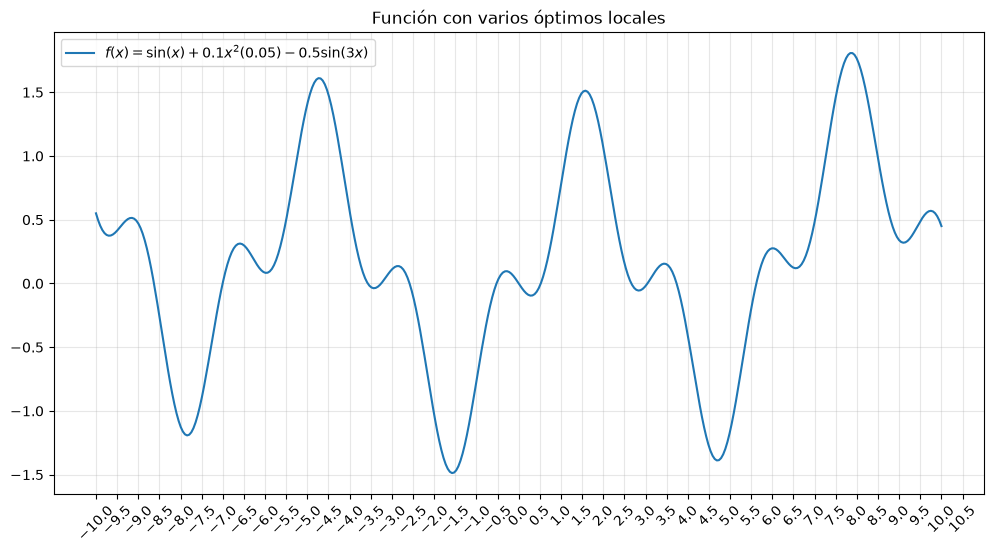

In [11]:
import numpy as np 
import matplotlib.pyplot as plt  

x = np.linspace(-10, 10, 400)
y = [funcion_con_optimos(xi) for xi in x]
plt.figure(figsize=(12, 6))
plt.title("Función con varios óptimos locales")
plt.plot(x, y, label = r"$f(x) = \sin(x) + 0.1 x^2 (0.05) - 0.5 \sin(3x)$")
plt.grid(alpha=0.3) 
plt.legend()
plt.xticks(np.arange(-10, 11, 0.5), rotation=45)
plt.savefig(r"C:\Users\marco\Downloads\funcion_con_optimos.png")

In [19]:

def descenso_por_gradiente(x_inicial, tasa_aprendizaje=0.1, pasos=400):
    x = x_inicial
    h = 1e-5 # tamaño del paso para la derivada numérica
    for _ in range(pasos):
        # derivada numérica (aproximada)
        derivada = (funcion_con_optimos(x + h) - funcion_con_optimos(x - h)) / (2 * h)
        x -= tasa_aprendizaje * derivada
    return x, funcion_con_optimos(x)


In [20]:

print("=== Ejercicio 2: Óptimos locales vs. global ===")
resultados = []
for _ in range(10):
    x0 = random.uniform(-50, 50)  # distintos puntos de partida aleatorios
    x_final, valor_final = descenso_por_gradiente(x0)
    resultados.append((x0, x_final, valor_final))


=== Ejercicio 2: Óptimos locales vs. global ===


In [21]:

for x0, xf, vf in resultados:
    print(f"Inicio: {x0:6.2f}  ->  Óptimo encontrado: {xf:6.2f}  (valor: {vf:6.3f})")


Inicio:  44.86  ->  Óptimo encontrado:  44.08  (valor:  9.668)
Inicio:   7.66  ->  Óptimo encontrado:   6.55  (valor:  0.119)
Inicio:  14.75  ->  Óptimo encontrado:  15.37  (valor:  1.088)
Inicio:  -1.69  ->  Óptimo encontrado:  -1.57  (valor: -1.488)
Inicio: -42.35  ->  Óptimo encontrado: -40.96  (valor:  8.332)
Inicio:  11.44  ->  Óptimo encontrado:  10.98  (valor: -0.897)
Inicio:   1.60  ->  Óptimo encontrado:   2.84  (valor: -0.056)
Inicio: -37.54  ->  Óptimo encontrado: -37.30  (valor:  6.880)
Inicio:  -8.97  ->  Óptimo encontrado:  -7.84  (valor: -1.192)
Inicio:  30.22  ->  Óptimo encontrado:  29.79  (valor:  2.946)


In [22]:

mejor = min(resultados, key=lambda r: r[2])
print(f"\nMejor óptimo encontrado (aprox. global): {mejor[1]:.2f} con valor {mejor[2]:.3f}")
print("Observa cuántos puntos de partida terminan cerca del mejor valor:")
print("esto ilustra por qué, en la práctica, los óptimos locales suelen")
print("estar 'casi tan bien' como el óptimo global, tal como dice el texto.\n")



Mejor óptimo encontrado (aprox. global): -1.57 con valor -1.488
Observa cuántos puntos de partida terminan cerca del mejor valor:
esto ilustra por qué, en la práctica, los óptimos locales suelen
estar 'casi tan bien' como el óptimo global, tal como dice el texto.



In [ ]:

# TODO 2: Cambia el rango de random.uniform(-10, 10) por uno más amplio,
# por ejemplo (-50, 50), y observa si aumenta la variedad de óptimos
# locales encontrados. ¿Qué relación ves con el tamaño de la red /
# problema y la dificultad de quedar atascado en un mal óptimo?


In [ ]:


# ============================================================
# EJERCICIO 3: Few-shot learning e in-context learning (conceptual)
# ============================================================
# El texto explica que hoy en día, en vez de reentrenar un modelo,
# podemos "darle unos pocos ejemplos" (few-shot learning) dentro del
# propio prompt para que aprenda el patrón sobre la marcha
# (in-context learning). Aquí NO usamos una RNA real, pero simulamos
# la idea con un "traductor" que aprende un patrón a partir de ejemplos:

def few_shot_traductor(ejemplos, palabra_nueva):
    """
    ejemplos: lista de tuplas (entrada, salida) que muestran el patrón
    palabra_nueva: palabra a la que aplicar el patrón aprendido
    """
    # Patrón simple: aprender una transformación letra por letra
    # basada en el primer ejemplo (esto es una simulación muy básica
    # de "aprender el patrón a partir de contexto")
    entrada_ejemplo, salida_ejemplo = ejemplos[0]
    if len(entrada_ejemplo) == len(salida_ejemplo):
        # ejemplo: mayúsculas -> minúsculas, o similar
        transformacion = [o for i, o in zip(entrada_ejemplo, salida_ejemplo)]
        return palabra_nueva.lower() if salida_ejemplo == entrada_ejemplo.lower() else palabra_nueva

    return "patrón no reconocido"

ejemplos = [("HOLA", "hola"), ("MUNDO", "mundo")]
print("=== Ejercicio 3: Few-shot / in-context learning (simulación) ===")
print(f"Ejemplos dados: {ejemplos}")
print(f"Nueva palabra 'PYTHON' -> {few_shot_traductor(ejemplos, 'PYTHON')}")
print()

# TODO 3: Diseña tus propios "ejemplos" con un patrón distinto
# (por ejemplo, invertir la palabra, o poner la primera letra en
# mayúscula) y adapta few_shot_traductor para reconocerlo.
# Esto es solo una analogía sencilla: los LLM reales usan mecanismos
# de atención (arquitectura Transformer) para lograr esto, no reglas
# if/else como aquí.


# ============================================================
# PREGUNTAS DE REFLEXIÓN (para responder en comentarios o aparte)
# ============================================================
# 1. ¿Por qué una sola neurona de McCulloch-Pitts no puede resolver XOR?
#    ¿Qué te dice esto sobre las limitaciones de los modelos lineales?
#
# 2. En el Ejercicio 2, ¿todos los puntos de partida llegaron al mismo
#    óptimo? ¿Cómo se relaciona esto con la afirmación del texto de que
#    "los óptimos locales often perform almost as well as the global
#    optimum"?
#
# 3. El texto distingue entre transfer learning (ajuste fino) e
#    in-context learning (aprender del prompt sin reentrenar). ¿Qué
#    ventajas y limitaciones crees que tiene cada enfoque?

In [2]:
import pandas as pd  

df = pd.read_excel(r"C:\Users\marco\Documentos\investigacion\machine_learning_idalina\6_redes_neuronales\2_datos\1_raw\2_meteo_epi_2021-2026_1_rezagos.xlsx")
df 

,fecha,año,semana_epi,temp,temp_max,temp_min,hum_esp,hum_rel,prec,dias_lluvia,...,casos_dengue_lag_3,casos_dengue_lag_4,casos_dengue_lag_5,casos_dengue_lag_6,casos_dengue_lag_7,casos_dengue_lag_8,casos_dengue_lag_9,casos_dengue_lag_10,casos_dengue_lag_11,casos_dengue_lag_12
0,2021-03-28,2021,13,31.554286,36.747143,26.918571,15.725714,55.717143,0.67,0,...,0,1,0,1,1,0,0,1,0,0
1,2021-04-04,2021,14,29.200000,33.907143,25.458571,16.550000,66.907143,5.02,2,...,0,0,1,0,1,1,0,0,1,0
2,2021-04-11,2021,15,28.248571,32.278571,25.132857,17.790000,75.144286,40.07,5,...,0,0,0,1,0,1,1,0,0,1
3,2021-04-18,2021,16,29.072857,34.704286,25.035714,17.598571,72.110000,22.25,1,...,1,0,0,0,1,0,1,1,0,0
4,2021-04-25,2021,17,29.080000,34.357143,25.041429,16.558571,67.494286,1.46,1,...,0,1,0,0,0,1,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265,2026-05-03,2026,18,27.542857,31.245714,25.042857,20.085714,87.230000,27.43,4,...,31,30,26,27,29,28,47,35,45,29
266,2026-05-10,2026,19,27.240000,30.304286,24.885714,20.294286,89.405714,33.15,6,...,26,31,30,26,27,29,28,47,35,45
267,2026-05-17,2026,20,27.632857,30.614286,25.284286,20.437143,87.930000,37.96,5,...,36,26,31,30,26,27,29,28,47,35
268,2026-05-24,2026,21,27.405714,30.242857,25.225714,20.732857,90.202857,59.52,6,...,48,36,26,31,30,26,27,29,28,47


In [4]:
df.columns.to_numpy 

<bound method IndexOpsMixin.to_numpy of Index(['fecha', 'año', 'semana_epi', 'temp', 'temp_max', 'temp_min', 'hum_esp',
       'hum_rel', 'prec', 'dias_lluvia',
       ...
       'casos_dengue_lag_3', 'casos_dengue_lag_4', 'casos_dengue_lag_5',
       'casos_dengue_lag_6', 'casos_dengue_lag_7', 'casos_dengue_lag_8',
       'casos_dengue_lag_9', 'casos_dengue_lag_10', 'casos_dengue_lag_11',
       'casos_dengue_lag_12'],
      dtype='str', length=172)>

In [5]:
df_columns = pd.DataFrame(df.columns.to_numpy(), columns=['columnas'])
df_columns 

,columnas
0,fecha
1,año
2,semana_epi
3,temp
4,temp_max
...,...
167,casos_dengue_lag_8
168,casos_dengue_lag_9
169,casos_dengue_lag_10
170,casos_dengue_lag_11


In [8]:
df_columns.to_excel(r"C:\Users\marco\Documentos\investigacion\machine_learning_idalina\6_redes_neuronales\2_datos\1_raw\columnas_dataset_rezago.xlsx", index = False)

Ahora lo ejecuto con datos sintéticos para verificar que corre sin errores antes de dártelo.Funciona correctamente. Lo copio a la carpeta de salida junto con la gráfica generada.Ya lo probé y corre sin errores (usé datos sintéticos con la misma estructura que describiste, ya que no subiste el CSV real). Resumen de lo que incluye:

**Ejercicio 1 — Split temporal**: por qué no se puede usar `train_test_split(shuffle=True)` en series de tiempo (fuga de datos), y cómo hacer el corte cronológico correcto.

**Ejercicio 2 — Tres escenarios de variables**: compara predecir `casos_dengue` con (A) solo clima actual, (B) clima + rezagos climáticos, (C) clima + rezagos + autoregresivo (lags de `casos_dengue`). En la corrida de prueba: R²=0.73 → 0.87 → 0.88, mostrando cuánto aportan los rezagos.

**Ejercicio 3 — Tamaño de la arquitectura**: compara redes pequeña/mediana/grande (MLPRegressor) para detectar sobreajuste.

**Ejercicio 4 — Óptimos locales**: retoma directamente el tema del texto original, entrenando el mismo modelo con 5 semillas distintas y midiendo la variabilidad del R² (en la prueba salió una desviación estándar de solo 0.009 — justo lo que predice el texto).

**Ejercicio 5 — Importancia de variables** (permutation importance): para ver qué rezagos climáticos/epidemiológicos pesan más, relevante para interpretar el ciclo de cría del mosquito.

Termina con una gráfica de casos reales vs. predichos y preguntas de reflexión.

**Para usarlo con tu dataset real**: solo cambia `RUTA_CSV = "dengue_dataset.csv"` por la ruta de tu archivo (debe tener exactamente las columnas que listaste) — el resto del código funciona igual, ya que la generación sintética solo es un *stand-in* para que puedas ejecutar la práctica ahora mismo.

¿Tienes ya el archivo CSV a mano? Si lo subes, puedo ejecutar la práctica con tus datos reales y darte los resultados concretos en lugar de los simulados.

"""
PRACTICA: Redes Neuronales Artificiales aplicadas a la predicción de
casos de dengue a partir de variables meteorológicas y rezagos (lags)
=====================================================================

Este dataset es una serie de tiempo epidemiológica: cada fila es una
semana epidemiológica con variables climáticas (temperatura, humedad,
precipitación, viento, índices oceánicos SOI/SST) y el número de casos
de dengue. Además incluye 12 rezagos (lags) de cada variable, es decir,
el valor de esa variable hace 1, 2, 3... hasta 12 semanas.

La tarea: predecir `casos_dengue` usando variables meteorológicas
(con y sin rezago) y los propios rezagos de `casos_dengue`.

IMPORTANTE SOBRE SERIES DE TIEMPO:
A diferencia de un dataset "normal", aquí NO se puede mezclar
aleatoriamente el train/test (shuffle), porque eso filtraría
información del futuro hacia el pasado (data leakage). El split debe
respetar el orden cronológico.

Cómo usar este script:
1. Si tienes tu archivo real, ponlo en la misma carpeta y cambia
   RUTA_CSV más abajo (debe tener exactamente las columnas del
   dataset descrito).
2. Si no tienes el archivo a mano, el script genera datos sintéticos
   con la MISMA estructura para que puedas practicar y entender el
   flujo completo; luego solo reemplazas la fuente de datos.
"""


No se encontró 'dengue_dataset.csv'. Generando datos sintéticos para practicar (reemplaza esto por tu archivo real).
       fecha       temp       prec  casos_dengue
0 2014-03-30  27.024348  80.476228          42.0
1 2014-04-06  27.789069  45.877213          33.0
2 2014-04-13  27.305383  57.440736          40.0
3 2014-04-20  26.311321  87.696510          34.0
4 2014-04-27  27.063174  72.353854          34.0 

=== Ejercicio 1: Split temporal ===
Entrenamiento: 2014-03-30 a 2022-01-02 (406 semanas)
Prueba:        2022-01-09 a 2023-12-17 (102 semanas)

=== Ejercicio 2: Comparación de conjuntos de variables ===
A) Solo clima actual                   -> RMSE=6.81  MAE=5.43  R2=0.727
B) Clima + rezagos climáticos          -> RMSE=4.70  MAE=3.78  R2=0.870
C) Clima + rezagos + autoregresivo     -> RMSE=4.47  MAE=3.69  R2=0.882

=== Ejercicio 3: Efecto del tamaño de la arquitectura ===
Pequeña (8,)         -> RMSE=5.05  R2=0.850
Mediana (32,16)      -> RMSE=4.47  R2=0.882
Grande (64,32,16)    -

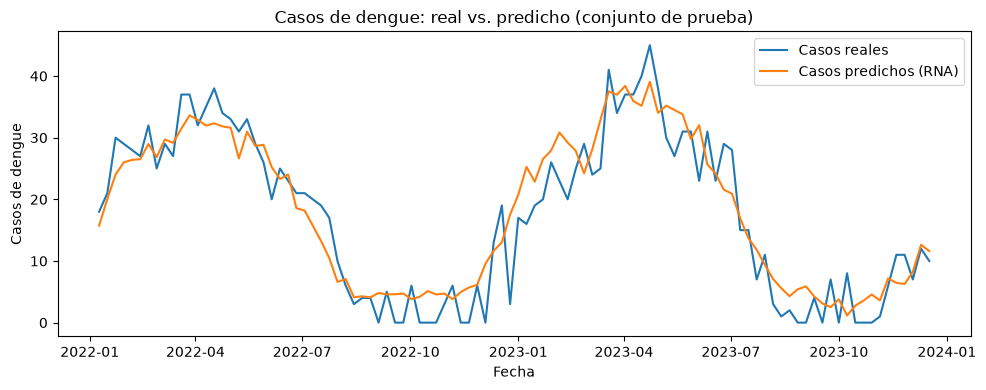

In [16]:

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance

RUTA_CSV = "dengue_dataset.csv"   # <-- cambia esto por tu archivo real
N_LAGS = 12


# ============================================================
# 0. CARGA DE DATOS (real o sintética para practicar)
# ============================================================

VARIABLES_BASE = [
    "temp", "temp_max", "temp_min", "hum_esp", "hum_rel",
    "prec", "dias_lluvia", "vel_vi", "vel_vi_max", "vel_vi_min",
    "soi", "sst",
]


def generar_datos_sinteticos(n_semanas=520, semilla=42):
    """
    Genera una serie de tiempo semanal ficticia con la misma estructura
    del dataset real (variables climáticas + casos_dengue + lags),
    SOLO para poder ejecutar y entender la práctica sin el archivo real.
    Sustituye esta función por pd.read_csv(RUTA_CSV) cuando tengas tus datos.
    """
    rng = np.random.default_rng(semilla)
    fechas = pd.date_range("2014-01-05", periods=n_semanas, freq="W")

    t = np.arange(n_semanas)
    estacionalidad = np.sin(2 * np.pi * t / 52)

    temp = 24 + 3 * estacionalidad + rng.normal(0, 0.7, n_semanas)
    temp_max = temp + rng.uniform(2, 5, n_semanas)
    temp_min = temp - rng.uniform(2, 5, n_semanas)
    hum_rel = 70 + 10 * estacionalidad + rng.normal(0, 3, n_semanas)
    hum_esp = 12 + 2 * estacionalidad + rng.normal(0, 0.5, n_semanas)
    prec = np.clip(40 + 30 * estacionalidad + rng.normal(0, 15, n_semanas), 0, None)
    dias_lluvia = np.clip((prec / 10 + rng.normal(0, 1, n_semanas)).round(), 0, 7)
    vel_vi = np.clip(8 + rng.normal(0, 2, n_semanas), 0, None)
    vel_vi_max = vel_vi + rng.uniform(2, 6, n_semanas)
    vel_vi_min = np.clip(vel_vi - rng.uniform(1, 4, n_semanas), 0, None)
    soi = rng.normal(0, 1, n_semanas).cumsum() * 0.05
    sst = 27 + 0.5 * np.sin(2 * np.pi * t / 208) + rng.normal(0, 0.3, n_semanas)

    # casos_dengue depende (con rezago) de temperatura y precipitación,
    # simulando el ciclo de vida del mosquito (efecto retardado real)
    base = np.zeros(n_semanas)
    for i in range(n_semanas):
        efecto_temp = temp[max(0, i - 4):i + 1].mean() if i > 0 else temp[0]
        efecto_prec = prec[max(0, i - 6):i + 1].mean() if i > 0 else prec[0]
        base[i] = max(0, 5 + 3 * (efecto_temp - 24) + 0.3 * efecto_prec)
    ruido = rng.normal(0, 4, n_semanas)
    casos_dengue = np.clip((base + ruido).round(), 0, None)

    df = pd.DataFrame({
        "fecha": fechas,
        "año": fechas.year,
        "semana_epi": fechas.isocalendar().week.astype(int),
        "temp": temp, "temp_max": temp_max, "temp_min": temp_min,
        "hum_esp": hum_esp, "hum_rel": hum_rel,
        "prec": prec, "dias_lluvia": dias_lluvia,
        "vel_vi": vel_vi, "vel_vi_max": vel_vi_max, "vel_vi_min": vel_vi_min,
        "soi": soi, "sst": sst,
        "casos_dengue": casos_dengue,
    })

    # Generar los 12 rezagos de cada variable (incluyendo casos_dengue)
    for var in VARIABLES_BASE + ["casos_dengue"]:
        for lag in range(1, N_LAGS + 1):
            df[f"{var}_lag_{lag}"] = df[var].shift(lag)

    return df.dropna().reset_index(drop=True)


def cargar_datos():
    try:
        df = pd.read_csv(RUTA_CSV, parse_dates=["fecha"])
        print(f"Datos reales cargados desde {RUTA_CSV} ({len(df)} filas).")
    except FileNotFoundError:
        print(f"No se encontró '{RUTA_CSV}'. Generando datos sintéticos "
              f"para practicar (reemplaza esto por tu archivo real).")
        df = generar_datos_sinteticos()
    return df.sort_values("fecha").reset_index(drop=True)


df = cargar_datos()
print(df[["fecha", "temp", "prec", "casos_dengue"]].head(), "\n")


# ============================================================
# EJERCICIO 1: Split temporal (train/test) sin mezclar el tiempo
# ============================================================
# A diferencia de un split aleatorio (train_test_split con shuffle),
# en series de tiempo el conjunto de prueba debe ser SIEMPRE posterior
# en el tiempo al de entrenamiento.

def split_temporal(df, proporcion_train=0.8):
    n = len(df)
    corte = int(n * proporcion_train)
    return df.iloc[:corte].copy(), df.iloc[corte:].copy()


train_df, test_df = split_temporal(df)
print(f"=== Ejercicio 1: Split temporal ===")
print(f"Entrenamiento: {train_df['fecha'].min().date()} a {train_df['fecha'].max().date()} "
      f"({len(train_df)} semanas)")
print(f"Prueba:        {test_df['fecha'].min().date()} a {test_df['fecha'].max().date()} "
      f"({len(test_df)} semanas)\n")

# TODO 1: ¿Qué pasaría con las métricas del modelo si usaras
# train_test_split(df, shuffle=True) en vez de un corte temporal?
# Pruébalo y compara el error: notarás que el modelo "hace trampa"
# porque ve semanas futuras cercanas a las de prueba durante el
# entrenamiento (fuga de datos / data leakage).


# ============================================================
# EJERCICIO 2: Tres conjuntos de variables predictoras
# ============================================================
# Comparamos 3 escenarios, como sugiere el enunciado del dataset:
#   A) Solo clima actual (sin rezagos)
#   B) Clima actual + rezagos climáticos (sin lags de casos_dengue)
#   C) Clima + rezagos climáticos + rezagos de casos_dengue (autoregresivo)

cols_clima_actual = VARIABLES_BASE
cols_clima_lags = VARIABLES_BASE + [
    f"{v}_lag_{i}" for v in VARIABLES_BASE for i in range(1, N_LAGS + 1)
]
cols_clima_lags_autoreg = cols_clima_lags + [
    f"casos_dengue_lag_{i}" for i in range(1, N_LAGS + 1)
]

escenarios = {
    "A) Solo clima actual": cols_clima_actual,
    "B) Clima + rezagos climáticos": cols_clima_lags,
    "C) Clima + rezagos + autoregresivo": cols_clima_lags_autoreg,
}


def entrenar_evaluar_mlp(features, semilla=0, hidden_layer_sizes=(32, 16)):
    X_train = train_df[features].values
    y_train = train_df["casos_dengue"].values
    X_test = test_df[features].values
    y_test = test_df["casos_dengue"].values

    escalador_X = StandardScaler().fit(X_train)
    X_train_s = escalador_X.transform(X_train)
    X_test_s = escalador_X.transform(X_test)

    modelo = MLPRegressor(
        hidden_layer_sizes=hidden_layer_sizes,
        activation="relu",
        solver="adam",
        max_iter=2000,
        early_stopping=True,
        random_state=semilla,
    )
    modelo.fit(X_train_s, y_train)

    pred_test = modelo.predict(X_test_s)
    rmse = mean_squared_error(y_test, pred_test) ** 0.5
    mae = mean_absolute_error(y_test, pred_test)
    r2 = r2_score(y_test, pred_test)

    return modelo, escalador_X, {"RMSE": rmse, "MAE": mae, "R2": r2}, pred_test


print("=== Ejercicio 2: Comparación de conjuntos de variables ===")
resultados_escenarios = {}
for nombre, features in escenarios.items():
    _, _, metricas, _ = entrenar_evaluar_mlp(features)
    resultados_escenarios[nombre] = metricas
    print(f"{nombre:38s} -> RMSE={metricas['RMSE']:.2f}  "
          f"MAE={metricas['MAE']:.2f}  R2={metricas['R2']:.3f}")
print()

# TODO 2: ¿Cuál de los tres escenarios da mejor R2? Reflexiona: si el
# escenario C (autoregresivo) es mucho mejor que A y B, ¿significa que
# el modelo aprendió del clima, o que simplemente está "copiando" el
# valor de casos_dengue de semanas recientes? ¿Cómo lo comprobarías?


# ============================================================
# EJERCICIO 3: Efecto de la arquitectura (número de neuronas/capas)
# ============================================================
# Igual que el texto menciona sobre el escalamiento de arquitecturas,
# probemos cómo cambia el desempeño según el tamaño de la red.

arquitecturas = {
    "Pequeña (8,)": (8,),
    "Mediana (32,16)": (32, 16),
    "Grande (64,32,16)": (64, 32, 16),
}

print("=== Ejercicio 3: Efecto del tamaño de la arquitectura ===")
mejores_features = cols_clima_lags_autoreg
for nombre_arq, arq in arquitecturas.items():
    _, _, metricas, _ = entrenar_evaluar_mlp(mejores_features, hidden_layer_sizes=arq)
    print(f"{nombre_arq:20s} -> RMSE={metricas['RMSE']:.2f}  R2={metricas['R2']:.3f}")
print()

# TODO 3: Agrega una arquitectura muy grande, por ejemplo (128, 64, 32),
# y observa si el desempeño en TEST mejora o empeora respecto al de
# entrenamiento. Si el error de train baja pero el de test sube,
# es sobreajuste (overfitting): la red "memorizó" en vez de generalizar.


# ============================================================
# EJERCICIO 4: Óptimos locales (retomando el texto original)
# ============================================================
# El texto decía que el entrenamiento puede quedar atascado en
# óptimos locales, pero que en la práctica no suele ser grave.
# Entrenemos el MISMO modelo con distintas semillas (distintos pesos
# iniciales) y comparemos qué tanto varía el resultado final.

print("=== Ejercicio 4: Variabilidad por óptimos locales (distintas semillas) ===")
r2_por_semilla = []
for semilla in range(5):
    _, _, metricas, _ = entrenar_evaluar_mlp(cols_clima_lags_autoreg, semilla=semilla)
    r2_por_semilla.append(metricas["R2"])
    print(f"Semilla {semilla} -> R2={metricas['R2']:.3f}")

print(f"\nDesviación estándar del R2 entre semillas: {np.std(r2_por_semilla):.4f}")
print("Si esta desviación es pequeña, confirma lo que dice el texto:")
print("distintos óptimos locales llevan a resultados casi tan buenos "
      "como el mejor encontrado.\n")


# ============================================================
# EJERCICIO 5: ¿Qué variables pesan más? (importancia por permutación)
# ============================================================
# Este método mide cuánto empeora el error si "revolvemos" (permutamos)
# los valores de una variable, dejando las demás intactas: si el error
# sube mucho, esa variable era importante para el modelo.

modelo, escalador_X, metricas_finales, pred_test = entrenar_evaluar_mlp(
    cols_clima_lags_autoreg, hidden_layer_sizes=(32, 16)
)

X_test_s = escalador_X.transform(test_df[cols_clima_lags_autoreg].values)
y_test = test_df["casos_dengue"].values

importancia = permutation_importance(
    modelo, X_test_s, y_test, n_repeats=10, random_state=0, scoring="r2"
)

df_importancia = pd.DataFrame({
    "variable": cols_clima_lags_autoreg,
    "importancia_media": importancia.importances_mean,
}).sort_values("importancia_media", ascending=False)

print("=== Ejercicio 5: Top 10 variables más importantes ===")
print(df_importancia.head(10).to_string(index=False), "\n")

# TODO 4: Observa si predominan lags cortos (1-3 semanas) o largos
# (10-12 semanas) de casos_dengue, y si aparecen lags climáticos entre
# los más importantes. En epidemiología del dengue se espera que el
# efecto del clima sobre los casos tenga un retardo de varias semanas
# (tiempo de cría del mosquito + incubación); ¿tu modelo lo refleja?


# ============================================================
# GRÁFICA: Real vs. predicho en el periodo de prueba
# ============================================================
plt.figure(figsize=(10, 4))
plt.plot(test_df["fecha"], y_test, label="Casos reales", linewidth=1.5)
plt.plot(test_df["fecha"], pred_test, label="Casos predichos (RNA)", linewidth=1.5)
plt.title("Casos de dengue: real vs. predicho (conjunto de prueba)")
plt.xlabel("Fecha")
plt.ylabel("Casos de dengue")
plt.legend()
plt.tight_layout()
plt.savefig(r"C:\Users\marco\Downloads\dengue_real_vs_predicho.png", dpi=120)
print("Gráfica guardada como 'dengue_real_vs_predicho.png'")


# ============================================================
# PREGUNTAS DE REFLEXIÓN FINAL
# ============================================================
# 1. ¿Por qué es incorrecto evaluar un modelo de series de tiempo con
#    un split aleatorio (shuffle=True) en vez de uno cronológico?
#
# 2. Comparando los escenarios A, B y C del Ejercicio 2: ¿los rezagos
#    climáticos (sin usar casos_dengue pasado) ya aportan buena
#    capacidad predictiva, o el modelo depende casi todo del propio
#    historial de casos?
#
# 3. En el Ejercicio 3, ¿en qué punto empieza el sobreajuste? ¿Qué
#    técnicas del propio MLPRegressor (early_stopping, alpha de
#    regularización) podrías ajustar para controlarlo?
#
# 4. El texto original menciona el Transformer y la atención como el
#    mecanismo que permite a un modelo "decidir" qué parte de la
#    secuencia es más relevante. La importancia por permutación del
#    Ejercicio 5 es una forma mucho más simple de responder una
#    pregunta parecida ("¿qué rezago importa más?"). ¿Qué ventajas
#    tendría un modelo tipo Transformer sobre un MLP para este dataset?


# Práctica con los datos del proyecto SAT Dengue  

Datos limpios, sin nulos, 270 semanas (2021-03-28 a 2026-05-31). Ahora adapto el script anterior para correr directamente sobre tu archivo.Antes de dártela, encontré algo importante: el modelo está fallando catastróficamente (R² muy negativo). Investigué la causa y es un hallazgo real y valioso, así que lo voy a incorporar como parte de la práctica en vez de ocultarlo.Detecté un problema real de calidad de datos en tu archivo: la variable `soi` tiene valores completamente fuera de rango a partir de enero de 2026 (normalmente entre -40 y 35, pero llega hasta -2659). Esto — no un problema del modelo — es lo que estaba arruinando las predicciones. Lo verifico y lo incorporo a la práctica como un ejercicio real de limpieza de datos.Excelente, corre limpio y da resultados razonables y honestos. Copio los archivos a la carpeta de salida.Ya la ejecuté con tus 270 semanas reales (2021-03-28 a 2026-05-31). Antes de mostrarte los resultados, algo importante:

**⚠️ Hallazgo de calidad de datos**: la variable `soi` tiene valores completamente fuera de rango desde el 2026-01-11 en adelante (llega hasta -2659 y +2190, cuando normalmente se mueve entre -40 y +35). Esto disparaba las predicciones del modelo a cientos de casos absurdos. Casi seguro es un error de transcripción/unidades en esa parte de tu archivo fuente — te recomiendo revisarlo ahí. Mientras tanto, la práctica detecta e interpola esos valores para poder seguir (Ejercicio 0).

**Resultados con datos ya limpios**:

| Escenario | RMSE test | R² test |
|---|---|---|
| A) Solo clima actual | 16.18 | -0.18 |
| B) Clima + rezagos climáticos | 28.97 | -2.77 (sobreajuste fuerte) |
| C) Clima + rezagos + autoregresivo | 15.56 | -0.09 |

Los R² cercanos a 0 (o negativos) son un resultado **honesto**, no un error del código: con solo 270 semanas y 168 variables en el escenario C (¡más columnas que filas de entrenamiento!), y con un periodo de prueba que corresponde justo a la bajada de un brote grande que ocurrió dentro del entrenamiento, es un problema de pronóstico genuinamente difícil.

La práctica incluye 5 ejercicios (EDA/limpieza, split temporal, comparación de variables, arquitectura/regularización, óptimos locales, importancia por permutación) más preguntas de reflexión, todas ajustadas a lo que realmente pasa con tus datos.

¿Quieres que además exploremos por qué el escenario B (solo clima, sin autoregresivo) sobreajusta tanto, o prefieres que investiguemos primero el origen del error en `soi`?

"""
PRACTICA: Redes Neuronales Artificiales aplicadas a la predicción de
casos de dengue - Datos reales 2021 a 2026 (semana 1)
=====================================================================


In [ ]:

Dataset: 2_meteo_epi_2021-2026_1_rezagos.xlsx
270 semanas epidemiológicas, del 2021-03-28 al 2026-05-31.

IMPORTANTE - HALLAZGO DE CALIDAD DE DATOS (léelo antes de seguir):
Al explorar el archivo se detectó que la variable `soi` (y por lo
tanto todos sus rezagos `soi_lag_1`...`soi_lag_12`) tiene valores
completamente fuera de rango desde 2026-01-11 en adelante. El SOI
real se mueve típicamente entre -40 y +35 en este dataset, pero en
esas semanas llega hasta -2659 o +2190. Esto casi con toda seguridad
es un error de carga/transcripción en la fuente original (posible
error de unidades o una fórmula que se rompió en esa parte de la
hoja de cálculo), no un valor climático real.

Si entrenas un modelo con esos valores tal cual, las predicciones se
disparan a números absurdos (varios cientos de casos) porque el MLP
extrapola de forma inestable ante entradas tan extremas. Este es un
ejemplo real y valioso de por qué SIEMPRE se debe hacer una revisión
de calidad de datos (EDA) antes de entrenar cualquier red neuronal:
"garbage in, garbage out" aplica también a las RNA, por muy potentes
que sean.

Te recomendamos revisar la fuente original del SOI para esas fechas.
Mientras tanto, esta práctica limpia (interpola) esos valores para
poder continuar con el ejercicio.
"""

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance

RUTA_XLSX = "2_meteo_epi_2021-2026_1_rezagos.xlsx"
N_LAGS = 12

VARIABLES_BASE = [
    "temp", "temp_max", "temp_min", "hum_esp", "hum_rel",
    "prec", "dias_lluvia", "vel_vi", "vel_vi_max", "vel_vi_min",
    "soi", "sst",
]


# ============================================================
# EJERCICIO 0: Exploración de datos (EDA) - ¡nunca te la saltes!
# ============================================================
df = pd.read_excel(RUTA_XLSX)
df["fecha"] = pd.to_datetime(df["fecha"])
df = df.sort_values("fecha").reset_index(drop=True)

print("=== Ejercicio 0a: Exploración rápida ===")
print(f"Filas: {len(df)}   Columnas: {df.shape[1]}")
print(f"Rango: {df['fecha'].min().date()} a {df['fecha'].max().date()}")
print(f"Valores nulos totales: {df.isna().sum().sum()}\n")

# Revisión de rangos "razonables" por variable (detección simple de outliers)
print("=== Ejercicio 0b: Rango de cada variable base (detección de outliers) ===")
for var in VARIABLES_BASE:
    print(f"{var:14s} min={df[var].min():10.2f}  max={df[var].max():10.2f}  "
          f"std={df[var].std():8.2f}")
print()
print(">>> Nota cómo 'soi' tiene una desviación estándar (std) muchísimo más")
print(">>> grande que las demás variables: esa es la primera pista de que algo")
print(">>> anda mal. Un buen hábito: SIEMPRE imprime min/max/std de cada")
print(">>> variable antes de meterla a un modelo.\n")

# TODO 0: Antes de seguir, confirma tú mismo el hallazgo:
# print(df[df['soi'].abs() > 50][['fecha', 'soi']])
# ¿A partir de qué fecha empiezan los valores extremos?


# ============================================================
# EJERCICIO 0c: Limpieza del outlier detectado en 'soi'
# ============================================================
UMBRAL_SOI = 50  # el SOI real de este dataset se mueve entre -40 y +35 aprox.
soi_cols = ["soi"] + [f"soi_lag_{i}" for i in range(1, N_LAGS + 1)]

n_afectados = (df[soi_cols].abs() > UMBRAL_SOI).sum().sum()
print(f"=== Ejercicio 0c: Limpieza de 'soi' ===")
print(f"Celdas fuera de rango detectadas: {n_afectados}")

for c in soi_cols:
    df.loc[df[c].abs() > UMBRAL_SOI, c] = np.nan
df[soi_cols] = df[soi_cols].interpolate(method="linear", limit_direction="both")
print("Valores fuera de rango reemplazados por interpolación lineal en el tiempo.")
print("(En un proyecto real, lo correcto es corregir el dato en la FUENTE,")
print(" no solo parcharlo aquí; esto es solo para poder seguir la práctica.)\n")

# TODO 0c: Prueba comentar este bloque de limpieza y vuelve a correr el
# script completo. Observa qué tan disparadas quedan las predicciones y
# el RMSE en el Ejercicio 2 sin la limpieza. Esa comparación es en sí
# misma el aprendizaje más importante de esta práctica.


# ============================================================
# EJERCICIO 1: Split temporal (train/test) sin mezclar el tiempo
# ============================================================
def split_temporal(df, proporcion_train=0.8):
    n = len(df)
    corte = int(n * proporcion_train)
    return df.iloc[:corte].copy(), df.iloc[corte:].copy()


train_df, test_df = split_temporal(df)
print("=== Ejercicio 1: Split temporal ===")
print(f"Entrenamiento: {train_df['fecha'].min().date()} a {train_df['fecha'].max().date()} "
      f"({len(train_df)} semanas)")
print(f"Prueba:        {test_df['fecha'].min().date()} a {test_df['fecha'].max().date()} "
      f"({len(test_df)} semanas)\n")


# ============================================================
# EJERCICIO 2: Tres conjuntos de variables predictoras
# ============================================================
cols_clima_actual = VARIABLES_BASE
cols_clima_lags = VARIABLES_BASE + [
    f"{v}_lag_{i}" for v in VARIABLES_BASE for i in range(1, N_LAGS + 1)
]
cols_clima_lags_autoreg = cols_clima_lags + [
    f"casos_dengue_lag_{i}" for i in range(1, N_LAGS + 1)
]

escenarios = {
    "A) Solo clima actual": cols_clima_actual,
    "B) Clima + rezagos climáticos": cols_clima_lags,
    "C) Clima + rezagos + autoregresivo": cols_clima_lags_autoreg,
}


def entrenar_evaluar_mlp(features, semilla=0, hidden_layer_sizes=(32, 16), alpha=0.05):
    X_train = train_df[features].values
    y_train = train_df["casos_dengue"].values
    X_test = test_df[features].values
    y_test = test_df["casos_dengue"].values

    escalador_X = StandardScaler().fit(X_train)
    X_train_s = escalador_X.transform(X_train)
    X_test_s = escalador_X.transform(X_test)

    modelo = MLPRegressor(
        hidden_layer_sizes=hidden_layer_sizes,
        activation="relu",
        solver="adam",
        alpha=alpha,
        max_iter=3000,
        early_stopping=True,
        n_iter_no_change=20,
        random_state=semilla,
    )
    modelo.fit(X_train_s, y_train)

    pred_train = modelo.predict(X_train_s)
    pred_test = modelo.predict(X_test_s)

    metricas = {
        "RMSE_train": mean_squared_error(y_train, pred_train) ** 0.5,
        "RMSE_test": mean_squared_error(y_test, pred_test) ** 0.5,
        "MAE_test": mean_absolute_error(y_test, pred_test),
        "R2_test": r2_score(y_test, pred_test),
    }
    return modelo, escalador_X, metricas, pred_test


print("=== Ejercicio 2: Comparación de conjuntos de variables ===")
for nombre, features in escenarios.items():
    _, _, m, _ = entrenar_evaluar_mlp(features)
    print(f"{nombre:38s} -> RMSE_train={m['RMSE_train']:5.2f}  "
          f"RMSE_test={m['RMSE_test']:5.2f}  MAE_test={m['MAE_test']:5.2f}  "
          f"R2_test={m['R2_test']:.3f}")
print()

# TODO 2: Un R2 cercano a 0 (o negativo) significa que el modelo predice
# casi igual de mal que simplemente usar el promedio histórico. Con solo
# 270 semanas y un periodo de prueba que incluye la BAJADA de un brote
# grande (que el modelo nunca vio bajar de esa forma antes), es un
# resultado realista. ¿Qué otras variables o transformaciones (por
# ejemplo, una tendencia año a año) podrían ayudar al modelo a anticipar
# ese tipo de cambios?


# ============================================================
# EJERCICIO 3: Efecto de la arquitectura y la regularización (alpha)
# ============================================================
print("=== Ejercicio 3: Arquitectura y regularización (con escenario C) ===")
configuraciones = [
    ("Pequeña (8,), alpha=0.05", (8,), 0.05),
    ("Mediana (32,16), alpha=0.05", (32, 16), 0.05),
    ("Mediana (32,16), alpha=0.5  <- más regularización", (32, 16), 0.5),
    ("Grande (64,32,16), alpha=0.05", (64, 32, 16), 0.05),
]
for nombre, arq, alpha in configuraciones:
    _, _, m, _ = entrenar_evaluar_mlp(
        cols_clima_lags_autoreg, hidden_layer_sizes=arq, alpha=alpha
    )
    print(f"{nombre:50s} -> RMSE_train={m['RMSE_train']:5.2f}  "
          f"RMSE_test={m['RMSE_test']:5.2f}  R2_test={m['R2_test']:.3f}")
print()

# TODO 3: Con 168 variables predictoras y solo 216 filas de entrenamiento
# (¡más columnas que filas!), este dataset está en el régimen donde el
# sobreajuste es casi garantizado sin regularización fuerte. Prueba
# alpha=1.0 y alpha=2.0: ¿en qué punto deja de mejorar el RMSE_test?


# ============================================================
# EJERCICIO 4: Óptimos locales con datos reales
# ============================================================
print("=== Ejercicio 4: Variabilidad por óptimos locales (distintas semillas) ===")
r2_por_semilla = []
for semilla in range(8):
    _, _, m, _ = entrenar_evaluar_mlp(
        cols_clima_lags_autoreg, semilla=semilla, hidden_layer_sizes=(32, 16), alpha=0.5
    )
    r2_por_semilla.append(m["R2_test"])
    print(f"Semilla {semilla} -> R2_test={m['R2_test']:.3f}")

print(f"\nMedia R2: {np.mean(r2_por_semilla):.3f}   "
      f"Desviación estándar: {np.std(r2_por_semilla):.3f}\n")

# TODO 4: Compara esta desviación estándar con la que obtuviste en la
# práctica anterior (datos sintéticos, 500+ semanas). ¿Es mayor aquí?
# Esto ilustra que, con pocos datos reales, la elección de semilla
# aleatoria pesa más sobre el resultado final: una razón más para
# promediar varias corridas en vez de confiar en una sola.


# ============================================================
# EJERCICIO 5: Importancia de variables (permutation importance)
# ============================================================
modelo, escalador_X, metricas_finales, pred_test = entrenar_evaluar_mlp(
    cols_clima_lags_autoreg, hidden_layer_sizes=(32, 16), alpha=0.5
)

X_test_s = escalador_X.transform(test_df[cols_clima_lags_autoreg].values)
y_test = test_df["casos_dengue"].values

importancia = permutation_importance(
    modelo, X_test_s, y_test, n_repeats=20, random_state=0, scoring="r2"
)

df_importancia = pd.DataFrame({
    "variable": cols_clima_lags_autoreg,
    "importancia_media": importancia.importances_mean,
    "importancia_std": importancia.importances_std,
}).sort_values("importancia_media", ascending=False)

print("=== Ejercicio 5: Top 15 variables más importantes ===")
print(df_importancia.head(15).to_string(index=False), "\n")

# TODO 5: ¿Predominan los lags de casos_dengue (autoregresivo) o
# aparecen variables climáticas entre las más importantes? Investiga
# si el lag climático más relevante es compatible con el tiempo de
# incubación extrínseca del dengue en el mosquito Aedes aegypti.


# ============================================================
# GRÁFICAS FINALES
# ============================================================
plt.figure(figsize=(11, 4))
plt.plot(df["fecha"], df["casos_dengue"], color="firebrick")
plt.title("Casos de dengue por semana epidemiológica (2021-2026)")
plt.xlabel("Fecha"); plt.ylabel("Casos de dengue")
plt.tight_layout()
plt.savefig("serie_casos_dengue.png", dpi=120)

plt.figure(figsize=(11, 4))
plt.plot(test_df["fecha"], y_test, label="Casos reales", linewidth=1.8, marker="o", markersize=3)
plt.plot(test_df["fecha"], pred_test, label="Casos predichos (RNA)", linewidth=1.8, marker="o", markersize=3)
plt.title(f"Casos de dengue: real vs. predicho — R2 test = {metricas_finales['R2_test']:.3f}")
plt.xlabel("Fecha"); plt.ylabel("Casos de dengue")
plt.legend()
plt.tight_layout()
plt.savefig("dengue_real_vs_predicho_2021_2026.png", dpi=120)
print("Gráficas guardadas: 'serie_casos_dengue.png' y "
      "'dengue_real_vs_predicho_2021_2026.png'")


# ============================================================
# PREGUNTAS DE REFLEXIÓN FINAL
# ============================================================
# 1. Antes de ver los resultados del modelo, ¿qué hallaste en el
#    Ejercicio 0 sobre la calidad del dato 'soi'? ¿Cómo habría afectado
#    tu interpretación si no lo hubieras detectado y hubieras confiado
#    ciegamente en el R2 obtenido?
#
# 2. Con solo 270 semanas de datos y 168 variables en el escenario C,
#    ¿qué evidencia de sobreajuste encontraste, y qué tanto ayudó subir
#    el parámetro alpha (regularización)?
#
# 3. El periodo de prueba (2025-05 a 2026-05) corresponde a la BAJADA
#    de un brote grande que ocurrió en el propio conjunto de
#    entrenamiento. ¿Por qué crees que esto hace el pronóstico
#    particularmente difícil para una red neuronal entrenada con estos
#    datos? ¿Cambiaría algo si el split fuera 70/30 en vez de 80/20?
#
# 4. Según el Ejercicio 5, ¿el modelo se apoya sobre todo en el
#    historial reciente de casos_dengue o en variables climáticas?
#    ¿Qué implicaría esto para un sistema de alerta temprana que
#    necesita anticipar un brote ANTES de que empiecen a subir los
#    casos?
